In [2]:
from google.colab import drive
import os

# Mount only if not already mounted
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("✅ Drive already mounted!")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

Mounted at /content/drive
✅ All libraries loaded!


In [3]:
df = pd.read_csv('/content/drive/MyDrive/house-price-project/data/processed/cleaned_housing.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (4856, 7)
Columns: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Price_log']


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Price_log
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,13.872868
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,14.224896
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,13.872825
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,14.047112
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,13.354973


In [4]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== CATEGORICAL COLUMNS ===")
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

print("\n=== NUMERICAL COLUMNS ===")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(num_cols)

=== DATA TYPES ===
Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Price_log                       float64
dtype: object

=== CATEGORICAL COLUMNS ===
[]

=== NUMERICAL COLUMNS ===
['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Price_log']


In [5]:
# USA Housing dataset has no categoricals after dropping Address
# But we write this code for completeness and Ames dataset later

# One-Hot Encoding example (if categorical columns exist)
if len(cat_cols) > 0:
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    print("✅ One-Hot Encoding applied!")
    print("New shape:", df.shape)
else:
    print("✅ No categorical columns found — already clean!")

print("\nColumns after encoding:")
print(df.columns.tolist())

✅ No categorical columns found — already clean!

Columns after encoding:
['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Price_log']


In [6]:
# Feature 1: Income per Room
df['Income_per_Room'] = df['Avg. Area Income'] / df['Avg. Area Number of Rooms']

# Feature 2: Bedroom to Room Ratio
df['Bedroom_Room_Ratio'] = df['Avg. Area Number of Bedrooms'] / df['Avg. Area Number of Rooms']

# Feature 3: Income x Population (interaction term)
df['Income_x_Population'] = df['Avg. Area Income'] * df['Area Population']

# Feature 4: Log of Income (reduce skewness)
df['Log_Income'] = np.log1p(df['Avg. Area Income'])

# Feature 5: Log of Population
df['Log_Population'] = np.log1p(df['Area Population'])

print("✅ New features created!")
print("New shape:", df.shape)
print("\nNew columns added:")
print(['Income_per_Room', 'Bedroom_Room_Ratio', 'Income_x_Population',
       'Log_Income', 'Log_Population'])
df.head()

✅ New features created!
New shape: (4856, 12)

New columns added:
['Income_per_Room', 'Bedroom_Room_Ratio', 'Income_x_Population', 'Log_Income', 'Log_Population']


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Price_log,Income_per_Room,Bedroom_Room_Ratio,Income_x_Population,Log_Income,Log_Population
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,13.872868,11348.740675,0.583520,1.836450e+09,11.284097,10.047060
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,14.224896,11773.993430,0.459082,3.183661e+09,11.280358,10.600977
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,13.872825,7199.463119,0.602627,2.260399e+09,11.023340,10.515510
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,14.047112,11338.520957,0.583526,2.173391e+09,11.056371,10.443228
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,13.354973,7651.387949,0.539583,1.580777e+09,11.001820,10.179417


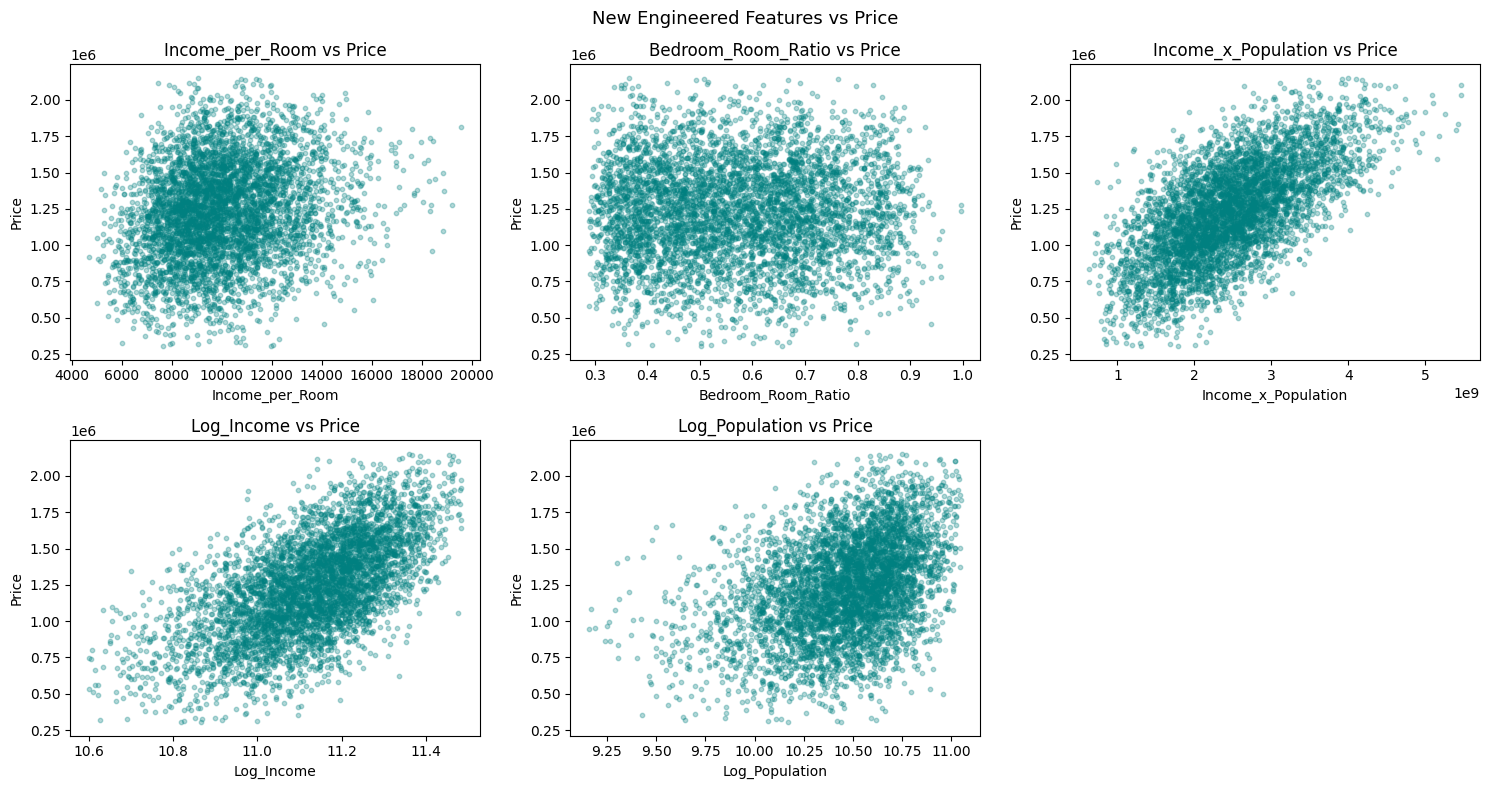

Saved!


In [7]:
new_features = ['Income_per_Room', 'Bedroom_Room_Ratio',
                'Income_x_Population', 'Log_Income', 'Log_Population']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(new_features):
    axes[i].scatter(df[col], df['Price'], alpha=0.3, s=10, color='teal')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'{col} vs Price')

# Hide last empty subplot
axes[5].set_visible(False)

plt.suptitle('New Engineered Features vs Price', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week3_plot1_new_features.png', dpi=150)
plt.show()
print("Saved!")

=== CORRELATION WITH PRICE ===
Price                           1.000000
Price_log                       0.977945
Income_x_Population             0.661090
Avg. Area Income                0.628735
Log_Income                      0.623803
Avg. Area House Age             0.439235
Area Population                 0.404683
Log_Population                  0.395399
Avg. Area Number of Rooms       0.327427
Income_per_Room                 0.217923
Avg. Area Number of Bedrooms    0.165503
Bedroom_Room_Ratio              0.018431
Name: Price, dtype: float64


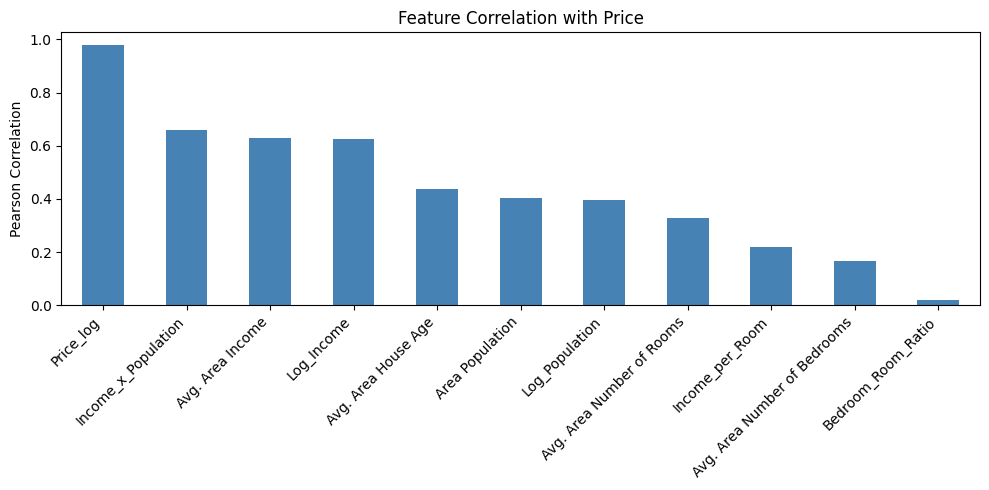

Saved!


In [8]:
# Drop non-numeric just in case
df_numeric = df.select_dtypes(include=[np.number])

corr_with_price = df_numeric.corr()['Price'].sort_values(ascending=False)
print("=== CORRELATION WITH PRICE ===")
print(corr_with_price)

# Plot
plt.figure(figsize=(10, 5))
corr_with_price.drop('Price').plot(kind='bar', color='steelblue')
plt.title('Feature Correlation with Price')
plt.ylabel('Pearson Correlation')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week3_plot2_correlation_bar.png', dpi=150)
plt.show()
print("Saved!")

In [9]:
# Drop features with correlation < 0.1 with Price
threshold = 0.1
low_corr = corr_with_price[abs(corr_with_price) < threshold].index.tolist()

# Remove Price itself from the list if present
low_corr = [col for col in low_corr if col != 'Price']

print("Low correlation features to drop:", low_corr)

df.drop(columns=low_corr, inplace=True)
print("\n✅ Low correlation features dropped!")
print("Remaining shape:", df.shape)
print("Remaining columns:", df.columns.tolist())

Low correlation features to drop: ['Bedroom_Room_Ratio']

✅ Low correlation features dropped!
Remaining shape: (4856, 11)
Remaining columns: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Price_log', 'Income_per_Room', 'Income_x_Population', 'Log_Income', 'Log_Population']


In [10]:
# Use Price_log as target if it exists, else use Price
if 'Price_log' in df.columns:
    target = 'Price_log'
    df.drop(columns=['Price'], inplace=True)
else:
    target = 'Price'

X = df.drop(columns=[target])
y = df[target]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())
print("Target:", target)

Features (X) shape: (4856, 9)
Target (y) shape: (4856,)

Feature columns: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Income_per_Room', 'Income_x_Population', 'Log_Income', 'Log_Population']
Target: Price_log


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Train/Test Split Done!")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

✅ Train/Test Split Done!
X_train shape: (3884, 9)
X_test shape: (972, 9)
y_train shape: (3884,)
y_test shape: (972,)


✅ Feature Scaling Done!

Before scaling - Avg. Area Income mean: 68552.91277837942
After scaling  - Avg. Area Income mean: -0.0


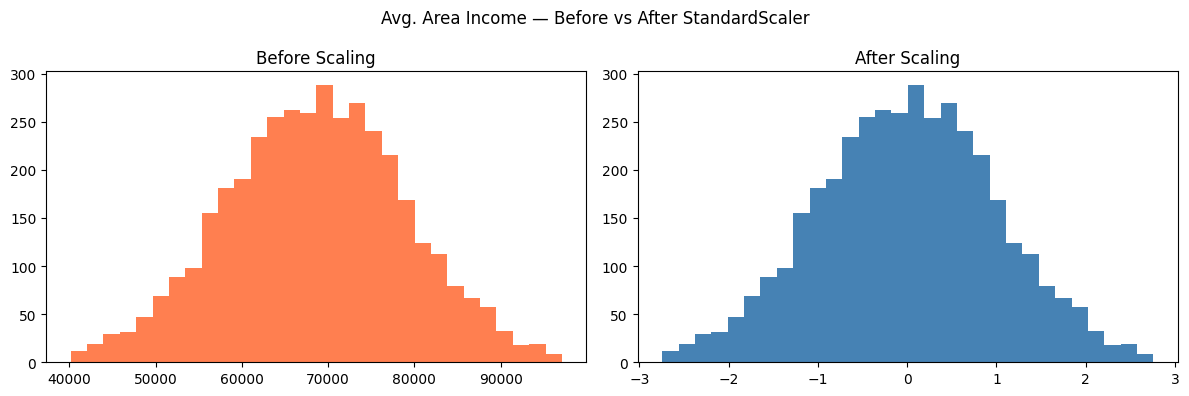

Saved!


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("✅ Feature Scaling Done!")
print("\nBefore scaling - Avg. Area Income mean:", X_train['Avg. Area Income'].mean())
print("After scaling  - Avg. Area Income mean:", round(X_train_scaled['Avg. Area Income'].mean(), 4))

# Visualize before vs after scaling
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train['Avg. Area Income'], bins=30, color='coral')
axes[0].set_title('Before Scaling')
axes[1].hist(X_train_scaled['Avg. Area Income'], bins=30, color='steelblue')
axes[1].set_title('After Scaling')
plt.suptitle('Avg. Area Income — Before vs After StandardScaler')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week3_plot3_scaling.png', dpi=150)
plt.show()
print("Saved!")

=== VIF SCORES ===
                        Feature         VIF
0              Avg. Area Income  122.299236
7                    Log_Income   92.004057
4               Area Population   65.526819
6           Income_x_Population   59.710070
5               Income_per_Room   33.921021
8                Log_Population   24.470310
2     Avg. Area Number of Rooms   17.301370
3  Avg. Area Number of Bedrooms    1.280370
1           Avg. Area House Age    1.001952

Note: VIF > 10 indicates high multicollinearity


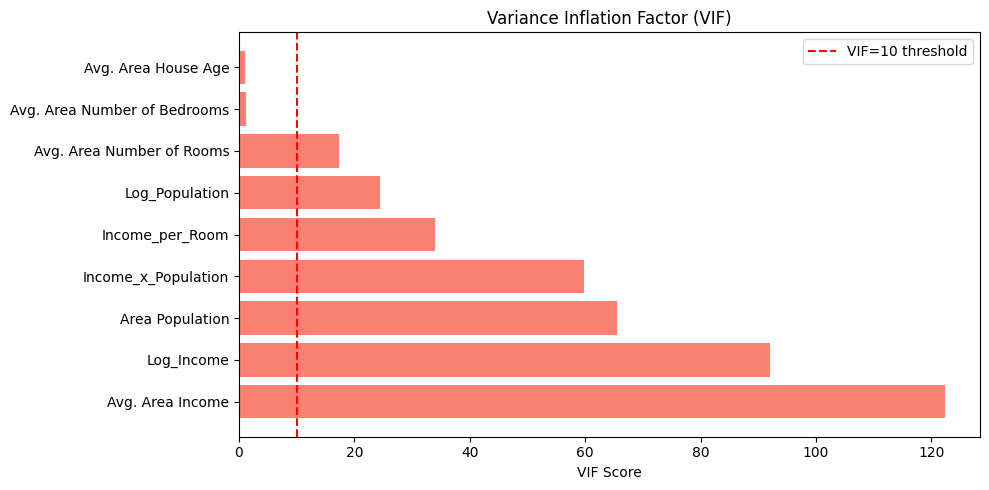

Saved!


In [13]:
# VIF check on scaled training data
vif_data = pd.DataFrame()
vif_data['Feature'] = X_train_scaled.columns
vif_data['VIF'] = [variance_inflation_factor(X_train_scaled.values, i)
                   for i in range(X_train_scaled.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False)
print("=== VIF SCORES ===")
print(vif_data)
print("\nNote: VIF > 10 indicates high multicollinearity")

# Plot VIF
plt.figure(figsize=(10, 5))
plt.barh(vif_data['Feature'], vif_data['VIF'], color='salmon')
plt.axvline(x=10, color='red', linestyle='--', label='VIF=10 threshold')
plt.title('Variance Inflation Factor (VIF)')
plt.xlabel('VIF Score')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/house-price-project/reports/week3_plot4_vif.png', dpi=150)
plt.show()
print("Saved!")

In [14]:
# Recursive Feature Elimination
lr = LinearRegression()
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X_train_scaled, y_train)

# Results
rfe_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values('Ranking')

print("=== RFE FEATURE RANKING ===")
print(rfe_df)

selected_features = rfe_df[rfe_df['Selected'] == True]['Feature'].tolist()
print("\n✅ Top 5 Selected Features:", selected_features)

=== RFE FEATURE RANKING ===
                        Feature  Selected  Ranking
1           Avg. Area House Age      True        1
2     Avg. Area Number of Rooms      True        1
6           Income_x_Population      True        1
4               Area Population      True        1
7                    Log_Income      True        1
5               Income_per_Room     False        2
8                Log_Population     False        3
0              Avg. Area Income     False        4
3  Avg. Area Number of Bedrooms     False        5

✅ Top 5 Selected Features: ['Avg. Area House Age', 'Avg. Area Number of Rooms', 'Income_x_Population', 'Area Population', 'Log_Income']


In [15]:
import os
os.makedirs('/content/drive/MyDrive/house-price-project/data/processed', exist_ok=True)

# Save all splits
X_train_scaled.to_csv('/content/drive/MyDrive/house-price-project/data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('/content/drive/MyDrive/house-price-project/data/processed/X_test.csv', index=False)
y_train.to_csv('/content/drive/MyDrive/house-price-project/data/processed/y_train.csv', index=False)
y_test.to_csv('/content/drive/MyDrive/house-price-project/data/processed/y_test.csv', index=False)

print("✅ All preprocessed files saved!")
print("Files saved:")
print("  - X_train.csv")
print("  - X_test.csv")
print("  - y_train.csv")
print("  - y_test.csv")

✅ All preprocessed files saved!
Files saved:
  - X_train.csv
  - X_test.csv
  - y_train.csv
  - y_test.csv


## Week 3 Summary — Feature Engineering & Data Preparation

**New Features Created:**
- Income_per_Room: Income divided by number of rooms
- Bedroom_Room_Ratio: Bedrooms to total rooms ratio
- Income_x_Population: Interaction term
- Log_Income: Log transform of income
- Log_Population: Log transform of population

**Feature Selection:**
- Dropped features with correlation < 0.1 with Price
- RFE selected top 5 most important features

**Scaling:** StandardScaler applied to all features

**Multicollinearity:** VIF checked — features with VIF > 10 noted

**Train/Test Split:** 80% train, 20% test (random_state=42)

**Files Saved:**
- X_train.csv, X_test.csv, y_train.csv, y_test.csv

**Next Step:** Week 4 — Linear Regression Model